In [41]:
import pandas as pd
import numpy as np
import sklearn
from sklearn import linear_model
from sklearn.utils import shuffle
import matplotlib.pyplot as pyplot
from matplotlib import style

In [42]:
# Read and load data 
data = pd.read_csv("data.csv")
# This is the attributes that will be used
#[["date", "price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront", "view", "sqft_above", "sqft_basement", "yr_built", "yr_renovated", "street", "city", "statezip", "country"]]
data = data[["price", "bedrooms", "bathrooms", "sqft_living", "yr_built"]]
# check the data 
data.head()

,price,bedrooms,bathrooms,sqft_living,yr_built
0,313000.0,3.0,1.50,1340,1955
1,2384000.0,5.0,2.50,3650,1921
2,342000.0,3.0,2.00,1930,1966
3,420000.0,3.0,2.25,2000,1963
4,550000.0,4.0,2.50,1940,1976


In [43]:
# This is the feature that will be predicted
predict = "price"
# create a new array after removing "price" so that it can be predicted
x = np.array(np.delete(data, 0, axis=1))
y = np.array(data[predict]/1000)

In [44]:
best_score = 0
for _ in range(10000):
    # split into training and testing sets
    x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(x, y, test_size=0.1)
    # creates a linear model
    linear = linear_model.LinearRegression()
    # fit the data to a linear model
    linear.fit(x_train, y_train)
    # check the accuracy of the model
    accuracy = linear.score(x_test, y_test)
    # checks for the best score
    if accuracy > best_score:
        best_score = accuracy

print(best_score)

0.6526813736821471


In [45]:
# take x_test (unused) array and predict "price" results
predictions = linear.predict(x_test)

for val in range(len(predictions)):
    # displays the predicted results, "x_test" input, and the actual result output from "y_test"
    print(predictions[val], x_test[val], y_test[val])

510.8594861772017 [3.000e+00 1.750e+00 2.170e+03 1.986e+03] 510.0
382.08116605221403 [   5.      2.25 2000.   1986.  ] 0.0
938.0728545175543 [4.000e+00 2.750e+00 3.370e+03 1.948e+03] 813.0
560.0201658460855 [   3.     2.5 2370.  2009. ] 429.9
524.9077254064623 [   4.      2.25 2250.   1980.  ] 569.0
527.0306052701562 [2.000e+00 1.000e+00 1.770e+03 1.943e+03] 243.0
389.12892307896254 [2.00e+00 1.00e+00 1.20e+03 1.94e+03] 450.0
551.7077059315525 [3.000e+00 1.500e+00 2.060e+03 1.953e+03] 450.0
636.4964112703674 [   3.      2.75 2580.   2008.  ] 437.0
449.5974584073956 [3.000e+00 1.000e+00 1.670e+03 1.939e+03] 460.0
468.9121685364589 [3.00e+00 1.00e+00 1.44e+03 1.91e+03] 560.0
465.1434193361729 [3.000e+00 1.500e+00 1.880e+03 1.968e+03] 405.0
417.5793565939166 [5.000e+00 1.500e+00 2.120e+03 1.962e+03] 290.0
711.6311751515759 [4.000e+00 2.500e+00 3.080e+03 1.997e+03] 635.0
823.3138786165264 [3.000e+00 2.500e+00 3.240e+03 1.994e+03] 800.0
432.16444125669386 [3.000e+00 1.750e+00 1.610e+03 1.96

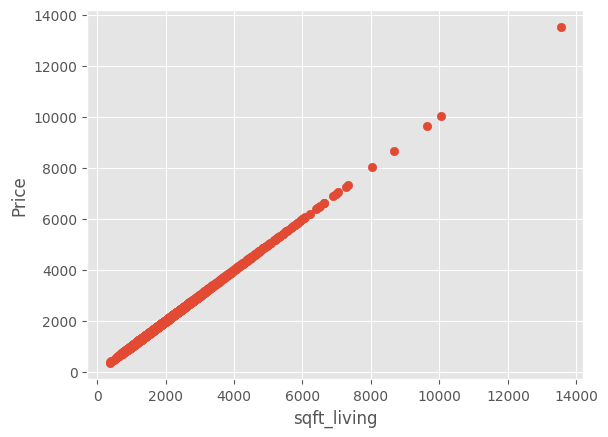

In [46]:
# print results on a graph
x_info = "sqft_living"
style.use("ggplot")
pyplot.scatter(data[x_info], data["sqft_living"])
pyplot.xlabel(x_info)
pyplot.ylabel("Price")
pyplot.show()